# Raytracing ray image

`batcamp` also provides an octree-aware ray tracer. This notebook follows the same pooch-fetched solar-corona dataset used in the larger quick start example, then builds one line-of-sight image: download and cache the file, build the octree objects, define one camera plane of parallel rays, render one image, and then inspect how many cells each ray crossed.


## Load one pooch-cached dataset and build the raytracing objects

This example uses the same solar-corona file as the second part of quick_start.ipynb, fetched from a larger archive with `pooch.retrieve(...)`. The file is downloaded once and then reused from the local pooch cache. Any of the provided files can be used here: `Octree.from_ds(ds)` reconstructs the appropriate tree directly from the dataset.


In [1]:
from batread import Dataset
import matplotlib.pyplot as plt
import numpy as np
import pooch

from batcamp import Octree, OctreeInterpolator, OctreeRayTracer
from batcamp.constants import XYZ_VARS

[sc_file] = pooch.retrieve(
    url="https://zenodo.org/records/7110555/files/run-Sun-G2211.tar.gz",
    known_hash="c31a32aab08cc20d5b643bba734fd7220e6b369e691f55f88a3a08cc5b2a2136",
    progressbar=True,
    processor=pooch.Untar(
        members=["run-Sun-G2211/SC/IO2/3d__var_4_n00044000.plt"],
    ),
)
print(f"{sc_file=}")

ds = Dataset.from_file(sc_file)
print(ds)

tree = Octree.from_ds(ds)
interp = OctreeInterpolator(tree, ds["Rho [g/cm^3]"])
tracer = OctreeRayTracer(tree)

print(tree)
print(interp)
print(tracer)


sc_file='/Users/dagfev/Library/Caches/pooch/8c62a596be9356ac52956bdee5198bec-run-Sun-G2211.tar.gz.untar/run-Sun-G2211/SC/IO2/3d__var_4_n00044000.plt'
Title:     'BATSRUS: 3D Data, 2011/02/16 17:26:00.000'
Zone:      '3D   N=0044000'
Variables: 24
Shape:     (532480, 24)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'ti [K]', 'te [K]', 'B_x [Gauss]', 'B_y [Gauss]', 'B_z [Gauss]', 'I01 [erg/cm^3]', 'I02 [erg/cm^3]', 'P [dyne/cm^2]', 'pe [dyne/cm^2]', 'E [erg/cm^3]', 'ehot [erg/cm^3]', 'qrad J/m^3/s', 'qheat J/m^3/s', 'refl 1/s', 'J_x [`mA/m^2]', 'J_y [`mA/m^2]', 'J_z [`mA/m^2]'].
Octree(tree_coord=rpa, root_shape=(1, 1, 2), leaf_shape=(64, 64, 128), leaf_cells=524288, runtime_cells=599186, levels=6..6)
OctreeInterpolator(tree_coord=rpa, n_points=532480, n_cells=524288, n_components=1)
OctreeRayTracer(tree_coord=rpa)


## Define one image plane of rays

The ray origins and directions are passed in Cartesian coordinates. To keep the example usable with any provided file, the image-plane bounds are taken directly from the dataset coordinates. The rays all start at one upstream $x$ position and travel in the $+x$ direction, so the ray origins form one `(ny, nz, 3)` array while the direction is one shared 3-vector.


In [5]:

y, z = np.meshgrid(
    np.linspace(-50, 50, 512), 
    np.linspace(-50, 50, 512), indexing="xy")

x = np.full_like(y, -450)

origins = np.stack((x, y, z), axis=-1)

directions = np.array([1.0, 0.0, 0.0], dtype=float)

print(f"origin grid shape: {origins.shape}")
print(f"shared direction shape: {directions.shape}")

origin grid shape: (512, 512, 3)
shared direction shape: (3,)


## Make one image

`trilinear_image` is the direct image path: it evaluates the interpolated density along each ray and integrates it over the traversed path segments. The output has the same image-plane shape as the input ray grid, so it can be plotted directly as one 2D image.


In [ ]:
rho_los, cell_counts = tracer.trilinear_image(interp, origins, directions)
print(f"image shape: {rho_los.shape}")
print(f"positive line integrals: min={rho_los.min():.3e}, max={rho_los.max():.3e}")

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
mesh = ax.pcolormesh(y, z, rho_los, shading="auto", norm="log")
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_title("Solar-corona ray-integrated density")
fig.colorbar(mesh, ax=ax, label="line integral of Rho [g/cm^3]")
plt.show()


## Inspect the returned traversal counts

The same `trilinear_image` call also returns one per-ray cell-count image. Plotting those counts gives one low-level view of the octree structure without tracing the same rays a second time.


cells per ray: min=0, median=48.0, max=220


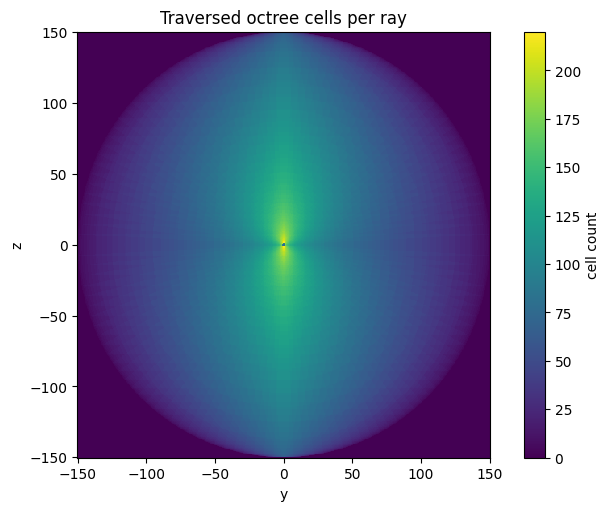

In [4]:
print(
    f"cells per ray: min={int(cell_counts.min())}, "
    f"median={float(np.median(cell_counts)):.1f}, "
    f"max={int(cell_counts.max())}"
)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
mesh = ax.pcolormesh(y, z, cell_counts, shading="auto")
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_title("Traversed octree cells per ray")
fig.colorbar(mesh, ax=ax, label="cell count")
plt.show()
